In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
# Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [3]:
from framework import sp_carga_exploracion as sc
from framework import sp_limpieza_transformacion as sl
from framework import sp_eda as se
from framework import sp_modelado as sm
from framework import sp_clustering as cl

In [4]:
df = sc.leer_csv('../data/processed/02_datos_limpios.csv')
df_e = df.copy()

CSV CARGADO
Archivo: ../data/processed/02_datos_limpios.csv
Filas:   1000
Columnas: 12


1️⃣ Las categóricas necesitan codificar_categoricas() antes de estandarizar_clustering()

estandarizar_clustering() solo sabe trabajar con números — si le pasas nivel_dificultad tal cual (texto), fallaría o la ignoraría. Así que reutilizamos el paso que ya conoces de sp_modelado.py antes de entrar en sp_clustering.py:

In [5]:
df_cluster = sm.codificar_categoricas(df_e, ['nivel_dificultad', 'horario_estudio_preferido', 'estilo_aprendizaje'])
df_cluster = df_cluster.drop(columns=['tiene_tutor'])   # nos quedamos con tiene_tutor_ml, como en modelado

### CON nota_final/aprobado

2️⃣ Aviso rápido sobre incluir aprobado + nota_final juntas

Como ya sabes, son la misma información dos veces (una se deriva de la otra). Para clustering no es "leakage" en el sentido estricto (no hay nada que predecir), pero sí puede hacer que el algoritmo agrupe en parte "por lo mismo dos veces" — dándole más peso implícito al rendimiento académico que al resto de variables. Como es para aprender, lo dejamos así y lo comentamos cuando veamos los resultados — es un buen ejercicio ver el efecto real, en vez de solo que te lo cuente.

Paso 1: preparación (estandarizar_clustering())

In [6]:
X_cluster, scaler_cluster = cl.estandarizar_clustering(df_cluster)
X_cluster.shape

(1000, 15)

Aquí no hace falta train_test() — a diferencia de regresión/clasificación, clustering no predice sobre datos nuevos en el mismo sentido, así que se usa el dataset completo (aunque a veces sí se reserva una muestra para validar clusters en producción, no es lo habitual en un ejercicio de curso).

15 columnas — coincide exactamente con lo esperado: 8 numéricas/binarias (horas_estudio_semanal, nota_anterior, tasa_asistencia, horas_sueno, edad, nota_final, aprobado, tiene_tutor_ml) + 7 dummies del One-Hot (2+2+3). Preparación correcta.

Paso 2: elegir el número de clusters

Aquí tienes dos métodos en tu caja de herramientas, y es buena práctica usar los dos juntos para decidir con más confianza — a veces uno sugiere un número y el otro lo confirma o lo cuestiona:

Cómo interpretar cada uno, antes de que los veas

Método del codo: busca visualmente el punto donde la curva de inercia deja de bajar tan rápido — como un "codo" en el gráfico. Es subjetivo (tú decides dónde está el codo mirando la imagen), pero es el más intuitivo para empezar.

Silhouette: te da un número objetivo (entre -1 y 1, cuanto más alto mejor) para cada k, y la función ya te dice directamente cuál es el mejor (print(f"Mejor k: {mejor_k}")) — más automático, menos subjetivo que el codo.

Si los dos coinciden en un número parecido, tienes buena confianza en la elección. Si difieren mucho, hay que pensarlo con más cuidado (o probar con el criterio de negocio: ¿tiene sentido interpretar 3 grupos de estudiantes? ¿5?).

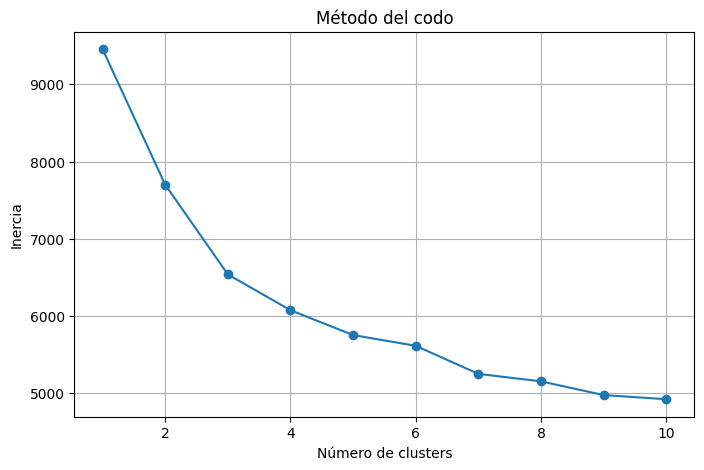

[9455.031999999988,
 7699.748894815511,
 6537.527904650564,
 6074.214639136071,
 5752.274544786314,
 5613.173642360337,
 5249.391360455853,
 5152.549808199864,
 4974.844816239503,
 4920.974032452999]

In [8]:
cl.metodo_codo(X_cluster, k_max=10)

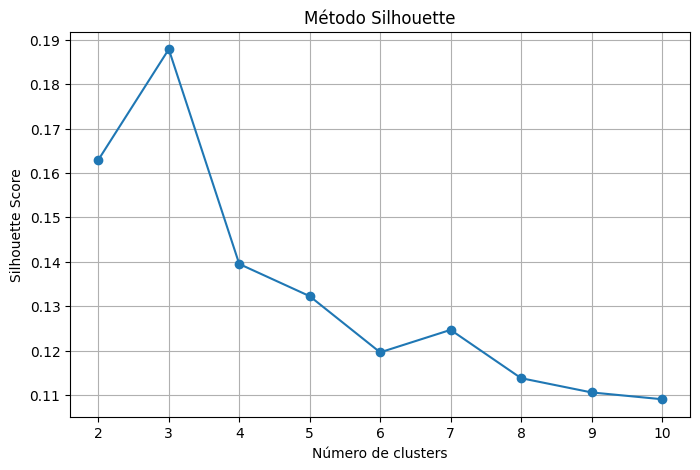

Mejor k: 3


(3, 0.18784453003373267)

In [9]:
cl.metodo_silhouette(X_cluster, k_max=10)

Los dos métodos coinciden claramente en k=3, y además con una lectura de calidad importante que hay que comentar antes de seguir.

Coincidencia entre los dos métodos
Codo: el descenso brusco de inercia se frena de forma visible justo después de k=2-3 (de 9455→7700→6538, y a partir de ahí la caída es mucho más suave) — el "codo" está ahí.
Silhouette: pico claro y único en k=3 (0,188), muy por encima de cualquier otro valor — de hecho es el único k con silhouette por encima de 0,16 salvo k=2.

Buena señal de que k=3 es una elección robusta, no arbitraria.

🟡 Aviso importante sobre la calidad de los clusters, antes de entusiasmarnos

El valor de silhouette en sí (0,188) es bajo. Como referencia orientativa: por encima de 0,5 se considera una estructura de clusters razonablemente clara; por debajo de 0,25, la separación entre grupos es débil — los clusters existen, pero se solapan bastante entre sí, no son "islas" muy distintas.

Esto es coherente con lo que ya sabíamos del EDA: la mayoría de tus variables tenían correlaciones moderadas, sin ninguna relación extremadamente fuerte ni patrones muy marcados. Es esperable que, si las variables individuales no tienen relaciones muy nítidas entre sí, tampoco formen grupos muy nítidos al combinarlas todas. No es un error tuyo ni del código — es reflejo del propio dataset.

No es un motivo para no seguir — a efectos de aprendizaje es perfectamente válido entrenar con k=3 e interpretar los perfiles, solo hay que ser honesto en el informe: los grupos van a ser una tendencia general, no compartimentos estancos y muy diferenciados entre sí.



Paso 3: entrenar con k=3

In [10]:
modelo_km, labels = cl.entrenar_kmeans(X_cluster, n_clusters=3)

Esto te va a dar tres números: Silhouette (el mismo 0,188 que ya viste, ahora confirmado sobre el modelo entrenado en concreto), Davies_Bouldin (cuanto más bajo, mejor — al revés que silhouette) e Inercia (la misma métrica del método del codo, ahora para tu k=3 concreto).

In [11]:
cl.evaluar_clustering(X_cluster, labels, modelo_km)

{'Silhouette': 0.18784453003373267,
 'Davies_Bouldin': 1.796142153819827,
 'Inercia': 6537.527904650564}

Coincide exactamente con lo que ya sabíamos por el codo/silhouette (buena señal de consistencia interna), y el Davies_Bouldin confirma la misma lectura de calidad moderada-baja que ya anticipamos.

Interpretando el Davies-Bouldin

Al revés que silhouette, aquí más bajo es mejor (0 sería el ideal teórico, clusters perfectamente separados). Tu 1,80 es un valor relativamente alto — refuerza lo que ya decíamos: los 3 grupos existen y son la mejor partición posible con estos datos, pero no están muy nítidamente separados entre sí, hay solape.

Antes de que lo veas, una explicación rápida de qué vas a mirar: tienes 15 dimensiones (columnas), imposibles de dibujar directamente. PCA las comprime a solo 2 "ejes resumen" (que mezclan un poco de todas las columnas originales) para poder verlo en un gráfico plano. Dado el silhouette bajo que ya sabemos, espera ver los 3 colores bastante mezclados/solapados entre sí, no 3 nubes de puntos claramente separadas — eso confirmaría visualmente lo que los números ya te decían.

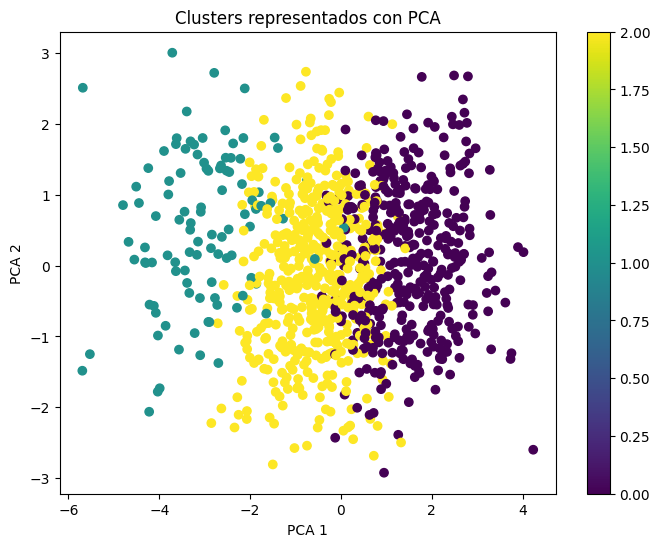

In [12]:
cl.visualizar_clusters_pca(X_cluster, labels)

Exactamente lo que anticipaba con el silhouette bajo: los grupos se ven, pero no son tres nubes limpiamente separadas. Vamos a leerlo con detalle:

Lo que sí se distingue
Morado (cluster 0): se concentra bastante en la zona derecha del gráfico (PCA 1 alto) — hay un núcleo relativamente reconocible.
Verde (cluster 1): se concentra en la izquierda (PCA 1 bajo) — también con un núcleo algo diferenciado, aunque más disperso.
Amarillo (cluster 2): ocupa sobre todo la zona central — y aquí está el problema: se solapa bastante con los otros dos en los bordes, especialmente con el morado.
Confirmación visual del silhouette bajo (0,188)

Si los clusters fueran nítidos, verías tres manchas de color bien separadas, casi sin mezcla en las fronteras. Aquí en cambio hay una zona central amplia donde los tres colores se entremezclan (sobre todo entre PCA 1 = -1 y 1) — eso es justo lo que un silhouette de 0,19 predice: existe una tendencia real (por eso k=3 ganó claramente a otros valores), pero las fronteras entre grupos son difusas, no compartimentos estancos.

Una precaución importante al interpretar este gráfico en concreto

Recuerda que PCA solo capta 2 ejes resumen de las 15 dimensiones originales — es posible que en el espacio de 15 dimensiones los clusters estén algo mejor separados de lo que aquí se ve, porque PCA necesariamente pierde información al comprimir. No hay que sacar conclusiones demasiado tajantes solo de esta imagen 2D; es una ayuda visual, no la prueba definitiva de calidad (para eso ya tienes el silhouette/Davies-Bouldin numéricos).

Paso 6, el más importante: interpretar qué es cada cluster

Esta es la parte que le da sentido a todo — vas a ver la media de cada variable numérica dentro de cada uno de los 3 grupos, y ahí es donde por fin vas a poder ponerles nombre (por ejemplo, "cluster de alto rendimiento", "cluster de bajo compromiso"...). Aquí también verás con claridad si el hecho de haber incluido nota_final/aprobado en el clustering hizo que los grupos se formaran principalmente en torno al rendimiento académico, tal como comentamos que podía pasar.

In [13]:
cl.perfil_clusters(df_cluster, labels)

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado,tiene_tutor_ml
Cluster,,,,,,,,
0,14.04,77.05,78.35,7.22,23.71,77.38,1.0,0.91
1,5.86,58.10,62.97,6.83,23.87,55.02,0.0,0.17
2,7.73,66.53,72.74,6.87,23.32,70.02,1.0,0.04


Excelente resultado para interpretar — los 3 clusters cuentan una historia con sentido de negocio muy clara, y confirma exactamente lo que sospechábamos sobre el efecto de incluir nota_final/aprobado.

Perfil de cada cluster

Cluster 0 — "Alto rendimiento, con apoyo"

- horas_estudio: 14,04 (la más alta)   
- nota_final: 77,38   
- aprobado: 100%   
- tiene_tutor: 91%

El grupo con mejores resultados en todo, y casi todos con tutor. Es el perfil "estudiante dedicado y acompañado".

Cluster 1 — "Bajo rendimiento, sin apoyo"

- horas_estudio: 5,86 (la más baja)   
- nota_final: 55,02   
- aprobado: 0%   
- tiene_tutor: 17%

Todos suspenden (aprobado=0,0 exacto) — este es el cluster donde se concentran los 102 suspensos del dataset. Menos horas de estudio, peor nota anterior, casi nadie tiene tutor.

Cluster 2 — "Rendimiento medio, autónomo"

- horas_estudio: 7,73   
- nota_final: 70,02   
- aprobado: 100%   
- tiene_tutor: 4% (casi ninguno)

Aprueban, con resultados moderados, pero destaca que casi nadie tiene tutor (4%, el más bajo de los tres) — es el perfil de estudiante que se las arregla solo, con un rendimiento decente sin necesitar apoyo externo.

Confirmación de lo que anticipamos sobre incluir el objetivo

Efectivamente, al incluir nota_final/aprobado, el algoritmo terminó organizando los 3 grupos casi enteramente en torno al rendimiento académico — el cluster 1 tiene 0% de aprobados exacto, algo que no pasaría por azar. Esto no es "malo" para el ejercicio de aprendizaje, pero hay que ser consciente de ello: el clustering aquí terminó pareciéndose mucho a una versión "descubierta sin supervisión" de la propia variable objetivo, no a un descubrimiento de patrones totalmente independiente del resultado.

Lo interesante — el matiz del tutor entre cluster 0 y 2

Este es el hallazgo más útil del ejercicio: hay dos caminos distintos hacia el aprobado — con mucho apoyo y muchas horas (cluster 0), o con pocas horas pero sin depender de tutor (cluster 2) — y ambos funcionan, aunque el primero da mejor nota media.

Clustering (k=3, exploratorio) — perfiles de estudiante

- Cluster 0 (alto rendimiento, con apoyo): 14h estudio/semana,
  nota_final 77,4, 100% aprobados, 91% con tutor.
- Cluster 1 (riesgo, sin apoyo): 5,9h estudio/semana, nota_final 55,0,
  0% aprobados, solo 17% con tutor.
- Cluster 2 (rendimiento medio, autónomo): 7,7h estudio/semana,
  nota_final 70,0, 100% aprobados, solo 4% con tutor.

Nota metodológica: al incluir nota_final/aprobado en las variables de
agrupación, los clusters se organizan principalmente en torno al
rendimiento académico. Silhouette=0,19 (moderado-bajo) indica
solapamiento entre grupos, coherente con las correlaciones moderadas
observadas en el EDA. Como ejercicio complementario, se recomendaría
repetir el clustering EXCLUYENDO nota_final/aprobado, para ver si
emergen perfiles de estudiante independientes del resultado (por
ejemplo, basados solo en hábitos de estudio y estilo de aprendizaje).

### SIN nota_final/aprobado

Vamos con la versión "pura" — solo perfil del estudiante, sin ningún rastro de su rendimiento. Esto sí es un clustering exploratorio real: descubrir si hay grupos naturales de estudiantes por hábitos, sin que el algoritmo sepa de antemano quién saca buena nota.

Preparación — mismo proceso, pero excluyendo las 2 columnas de resultado

In [14]:
df_cluster2 = df_cluster.drop(columns=['nota_final', 'aprobado'])
X_cluster2, scaler_cluster2 = cl.estandarizar_clustering(df_cluster2)
print(X_cluster2.shape)   # debería dar (1000, 13)

(1000, 13)


`Repetimos el mismo flujo completo`

Aquí no des por hecho que k=3 va a seguir siendo el mejor — sin nota_final/aprobado empujando la estructura, es totalmente posible que salga un k distinto (2, 4, o incluso que la estructura sea aún más débil que antes). Es precisamente lo interesante de comparar.

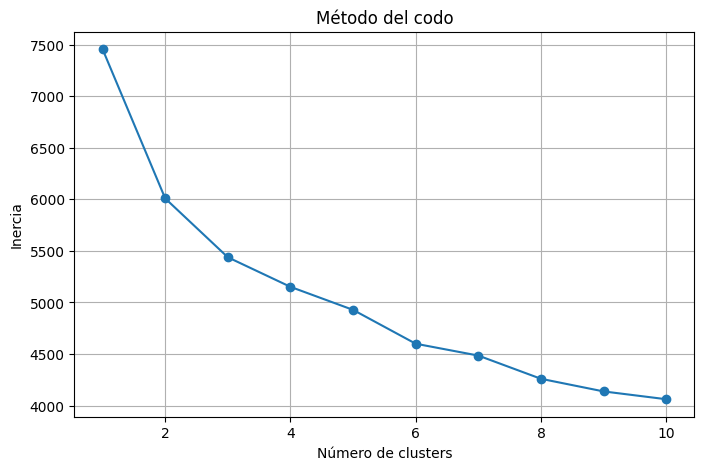

[7455.032000000004,
 6008.4829129654645,
 5437.995317031343,
 5151.343376775596,
 4928.018656648987,
 4599.97949230369,
 4485.005271259839,
 4259.988613445024,
 4137.606981055845,
 4061.97454288246]

In [15]:
cl.metodo_codo(X_cluster2, k_max=10)

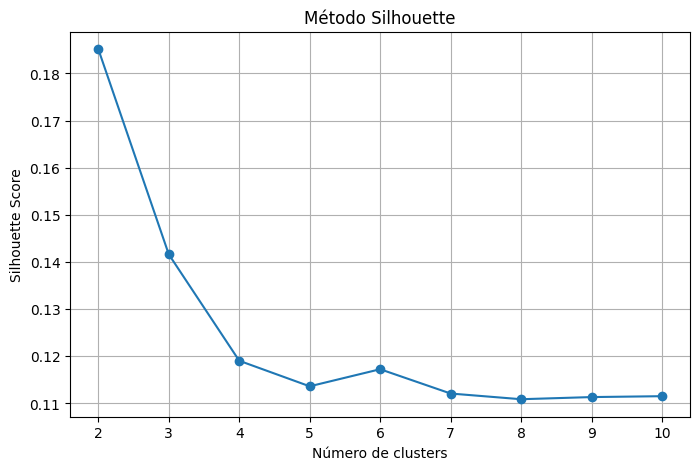

Mejor k: 2


(2, 0.18515062938652574)

In [16]:
cl.metodo_silhouette(X_cluster2, k_max=10)


Confirmado exactamente lo que anticipábamos: sin nota_final/aprobado, la estructura cambia — ahora el mejor k es 2, no 3.

Comparación directa entre las dos versiones

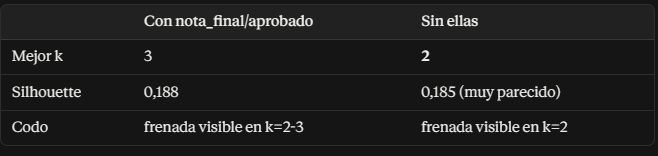

Lo primero que llama la atención: la calidad (silhouette) es prácticamente idéntica (0,188 vs 0,185) — quitar el rendimiento académico no empeoró la estructura de los datos, simplemente cambió su forma: de 3 grupos a 2. Esto es una pista importante: parece que existe una estructura real de "2 perfiles de hábitos de estudio" en el dataset, independiente de la nota, y que al meter nota_final/aprobado antes, el algoritmo "partía" uno de esos 2 grupos en dos (probablemente separando dentro de un mismo perfil de hábitos a los que sacaron mejor y peor nota por azar/otros factores).

Paso 3: entrenar con k=2

In [18]:
modelo_km2, labels2 = cl.entrenar_kmeans(X_cluster2, n_clusters=2)

Paso 4: evaluación

Aunque ya sabemos el silhouette (0,185, lo vimos en el gráfico de antes), evaluar_clustering() también te va a dar Davies_Bouldin e Inercia para este modelo concreto (con k=2), que no tenemos todavía

In [19]:
cl.evaluar_clustering(X_cluster2, labels2, modelo_km2)

{'Silhouette': 0.18515062938652574,
 'Davies_Bouldin': 1.968102060368996,
 'Inercia': 6008.4829129654645}

Paso 5: visualización con PCA

el PCA nos va a decir si, con solo 2 grupos en vez de 3, la separación visual es más clara que la primera vez (con menos grupos, suele ser más fácil que se vean separados)

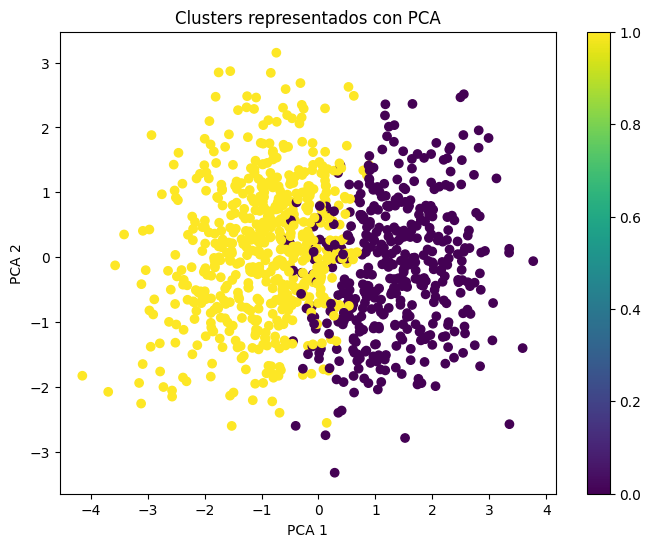

In [20]:
cl.visualizar_clusters_pca(X_cluster2, labels2)

Aquí sí se ve una separación mucho más limpia que en el primer experimento (k=3) — con solo 2 grupos, la frontera entre morado y amarillo es bastante más clara, con menos zona de solapamiento en el centro. Aun así, el Davies_Bouldin (1,97) sale ligeramente peor que el de la primera versión (1,80) — un matiz interesante que merece explicarse, porque a primera vista el gráfico "se ve mejor" pero el número dice lo contrario.

Por qué el gráfico parece más limpio pero el Davies-Bouldin es peor

No es una contradicción — son cosas distintas:

- El PCA solo muestra 2 de las 13 dimensiones (comprimidas) — con menos clusters (2 en vez de 3), es matemáticamente más fácil que se vean "separados" en el plano, simplemente porque hay menos fronteras que dibujar.
- Davies-Bouldin se calcula sobre las 13 dimensiones reales, no sobre la versión comprimida de 2 — y ahí, el hecho de tener menos variables de entrada en general (13 en vez de 15, sin nota_final/aprobado) hace que cada cluster tenga, en las dimensiones que sí importan, algo más de dispersión interna relativa.

En resumen: visualmente se ve más limpio, mide (en las dimensiones reales) un pelín peor, pero la diferencia (1,80 vs 1,97) es pequeña — no cambiaría la conclusión de que es un experimento válido y coherent

Resumen final de los 4 pasos que faltaban, y cierre del clustering

- Silhouette:&nbsp;&nbsp;      0,185  (casi igual que la versión con objetivo, 0,188)
- Davies_Bouldin:&nbsp;&nbsp; 1,968  (ligeramente peor que 1,796, pero sin diferencia relevante)
- Inercia:&nbsp;&nbsp; 6008,5
- PCA:&nbsp;&nbsp; separación visual más clara que con k=3, aunque con zona de solape central

Evaluación completa — clustering sin objetivo (k=2)

Silhouette=0,185, Davies_Bouldin=1,968, Inercia=6008,5. La
visualización PCA muestra una frontera más clara entre los 2 grupos
que en la versión con 3 clusters, aunque persiste cierto solape
central — coherente con la naturaleza moderada de las relaciones
entre variables observadas en todo el proyecto.

In [ ]:

cl.perfil_clusters(df_cluster2, labels2)

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,tiene_tutor_ml
Cluster,,,,,,
0,13.76,76.03,77.12,7.23,23.67,0.93
1,7.36,65.36,71.69,6.84,23.43,0.02


Justo lo que anticipábamos: emergen 2 perfiles de hábitos, muy parecidos a los clusters 0 y 2 de la primera versión, pero ahora sin que el algoritmo haya "sabido" nada de las notas para construirlos.

Los 2 perfiles puros

Cluster 0 — "Con tutor, alta dedicación"

horas_estudio: 13,76   nota_anterior: 76,03   tasa_asistencia: 77,12   tiene_tutor: 93%

Cluster 1 — "Sin tutor, dedicación moderada"

horas_estudio: 7,36   nota_anterior: 65,36   tasa_asistencia: 71,69   tiene_tutor: 2%

El hallazgo real de este segundo experimento

Sin haberle dado ninguna pista sobre notas, el algoritmo separó a los estudiantes casi exclusivamente por si tienen tutor o no (93% vs 2% — prácticamente una frontera perfecta) — y ese único factor arrastra consigo, de forma natural, más horas de estudio, más asistencia y mejor nota anterior. Esto confirma con mucha fuerza el hallazgo de correlación que vimos al principio del EDA (tiene_tutor_ml ↔ horas_estudio_semanal, r=0,593): es tan fuerte que, sin pedírselo, es el eje principal que el clustering encuentra por sí solo.

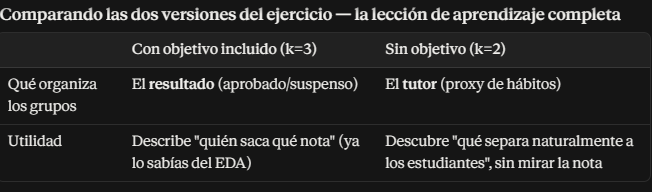

La versión sin objetivo es el ejercicio de clustering más "honesto" — es el que de verdad responde a la pregunta "¿qué grupos existen en los datos, sin que yo les diga qué buscar?". La primera versión (con nota_final) es más bien una forma indirecta de re-descubrir algo que ya sabías por el EDA (que las horas de estudio y el tutor predicen la nota), no un hallazgo nuevo.

Clustering — comparación con y sin variables objetivo

Se entrenaron dos versiones de KMeans sobre el mismo dataset:

1. CON nota_final/aprobado (k=3, silhouette=0,188): los clusters se
   organizan casi enteramente en torno al resultado académico
   (un cluster con 0% de aprobados exacto).

2. SIN nota_final/aprobado (k=2, silhouette=0,185): calidad
   prácticamente idéntica, pero la estructura cambia — emergen 2
   perfiles de estudiante definidos casi exclusivamente por tener
   tutor (93% vs 2%), que arrastra consigo más horas de estudio,
   mejor nota_anterior y más asistencia.

Conclusión: la versión SIN objetivo es la más informativa como
ejercicio de clustering puro, ya que revela un patrón estructural
del dataset (el efecto del tutor sobre el conjunto de hábitos)
sin depender de conocer previamente el resultado académico.